In [62]:
# from atmospheric_analysis import AtmosphericDiagnostics
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [63]:
import numpy as np
import dask.array as da
from dask.diagnostics import ProgressBar

class AtmosphericDiagnostics:
    """
    Perform general atmospheric diagnostics including:
    - Anomalies
    - Eddy Momentum Flux (EMF)
    - Eddy Heat Flux (EHF)
    - Meridional EMF gradient (dEMF/dy)
    """

    def __init__(self, u, v, t, p, lat=None, lon=None):
        """
        Parameters:
        - u, v, t, p: Arrays (NumPy or Dask) of shape (time, z, y, x)
        - lat, lon: Optional 1D arrays for latitude and longitude
        """
        self.u = u
        self.v = v
        self.t = t
        self.p = p

        self.time_dim, self.z_dim, self.y_dim, self.x_dim = u.shape
        self.lat = lat if lat is not None else np.linspace(-90, 90, self.y_dim)
        self.lon = lon if lon is not None else np.linspace(0, 360, self.x_dim)

    @staticmethod
    def anomaly(data, axis=-1):
        """Compute the anomaly by subtracting mean along axis."""
        mean = np.mean(data, axis=axis, keepdims=True)
        return data - mean

    @staticmethod
    def compute_if_dask(arr):
        """Compute the result if it's a Dask array."""
        return arr.compute() if isinstance(arr, da.Array) else arr

    @staticmethod
    def EMF_dask(u, v, axis=-1):
        """Eddy Momentum Flux: u'v' (Dask-compatible)."""
        u_prime = u - u.mean(axis=axis, keepdims=True)
        v_prime = v - v.mean(axis=axis, keepdims=True)
        return u_prime * v_prime
        
    @staticmethod
    def cal_theta(t, p, axis=-1):
        """Eddy Heat Flux: v'b' (Dask-compatible)."""
        Rd, Cp = 287.0, 1004.0
        exponent = Rd / Cp

        theta = t * (100000 / p) ** exponent
        return theta
        

    @staticmethod
    def EHF_dask(t, p, v, axis=-1):
        """Eddy Heat Flux: v'b' (Dask-compatible)."""
        # Rd, Cp = 287.0, 1004.0
        # exponent = Rd / Cp

        # theta = t * (100000 / p) ** exponent
        theta = AtmosphericDiagnostics.cal_theta(t, p)  
        theta_mean = theta.mean(axis=axis, keepdims=True)
        theta_prime = theta - theta_mean

        v_prime = v - v.mean(axis=axis, keepdims=True)
        b = (theta_prime / theta_mean) * 9.81
        b_prime = b - b.mean(axis=axis, keepdims=True)

        return v_prime * b_prime

    # def dEMF_dy(self, emf, use_dask=False):
    #     """
    #     Compute meridional gradient of EMF (∂(u'v')/∂y).
        
    #     Parameters:
    #     - emf: Array of shape (z, y, x)
    #     - use_dask: If True, compute gradient lazily using Dask

    #     Returns:
    #     - dEMF/dy: Array (NumPy or Dask depending on input)
    #     """
    #     R = 6.371e6
    #     lat_rad = np.radians(self.lat)
    #     dy = np.gradient(lat_rad) * R  # meters

    #     dy_broadcast = dy[np.newaxis, :, np.newaxis]

    #     if use_dask and isinstance(emf, da.Array):
    #         return emf.map_blocks(np.gradient, axis=-2) / dy_broadcast
    #     else:
    #         return np.gradient(emf, axis=-2) / dy_broadcast
    def dEMF_dy(self, emf, use_dask=True, progress=True, chunks=(10, 20, 64, 128)):
        """
        Efficient + accurate meridional gradient of EMF (∂(u'v')/∂y) with Dask support.
    
        Parameters:
        - emf: Array (time, z, y, x), either NumPy or Dask
        - use_dask: If True, compute using Dask (lazy until .compute())
        - progress: If True and use_dask is True, show progress bar
        - chunks: Tuple to use if converting NumPy array to Dask
    
        Returns:
        - dEMF_dy: NumPy array if computed, or Dask array if lazy
        """
        # Ensure emf is a Dask array
        emf_dask = da.from_array(emf, chunks=chunks) if not isinstance(emf, da.Array) else emf
    
        # Compute dy between latitudes in meters
        R = 6.371e6
        lat_rad = np.radians(self.lat)
        dy = np.gradient(lat_rad) * R  # shape (y,)
        dy_dask = da.from_array(dy, chunks=(chunks[2],))
        dy_broadcast = dy_dask[None, None, :, None]  # shape (1, 1, y, 1)
    
        # Compute meridional gradient using Dask
        d_emf_dy = da.gradient(emf_dask, axis=2) / dy_broadcast
    
        if use_dask:
            if progress:
                from dask.diagnostics import ProgressBar
                print("dEMF_dy progress:")
                with ProgressBar():
                    return d_emf_dy.compute()
            else:
                return d_emf_dy  # Lazy result
        else:
            # Fallback to NumPy gradient
            emf_np = emf.compute() if isinstance(emf, da.Array) else emf
            dy_np = dy[np.newaxis, :, np.newaxis]
            return np.gradient(emf_np, axis=2) / dy_np



    def run_emf_ehf(self, chunks=(10, 20, 64, 128), progress=True):
        """
        Convert inputs to Dask, compute EMF and EHF with optional progress bar.
        Returns computed NumPy arrays: emf, ehf
        """
        # Convert to Dask arrays if not already
        u_dask = da.from_array(self.u, chunks=chunks) if not isinstance(self.u, da.Array) else self.u
        v_dask = da.from_array(self.v, chunks=chunks) if not isinstance(self.v, da.Array) else self.v
        t_dask = da.from_array(self.t, chunks=chunks) if not isinstance(self.t, da.Array) else self.t
        p_dask = da.from_array(self.p, chunks=chunks) if not isinstance(self.p, da.Array) else self.p

        # Compute EMF & EHF lazily
        emf_lazy = self.EMF_dask(u_dask, v_dask)
        ehf_lazy = self.EHF_dask(t_dask, p_dask, v_dask)

        # Compute with progress bar
        if progress:
            print("EMF and EHF progress:")
            with ProgressBar():
                emf = emf_lazy.compute()
                ehf = ehf_lazy.compute()
        else:
            emf = emf_lazy.compute()
            ehf = ehf_lazy.compute()

        return emf, ehf

    def dtheta(self, theta, save=False, zonal_mean=True, output_dir=None, pr_id=None):
        """
        Compute vertical gradient of potential temperature ∂θ/∂z using central difference.
    
        Parameters:
        - theta: ndarray, shape (time, z, y, x)
        - save: bool, whether to save outputs as HDF5
        - zonal_mean: bool, whether to also compute and return zonal mean
        - output_dir: required if save=True, base path to save files
        - pr_id: required if save=True, identifier like 'PR10'
    
        Returns:
        - dtheta: ndarray, shape (time, z, y, x)
        - dtheta_zonal_mean: ndarray (time, z, y) if zonal_mean=True, else None
        """
        import os
        import gc
        import h5py
    
        print("Computing ∂θ/∂z ...")
        theta = np.asarray(theta)  # ensure numpy array
        t, z, y, x = theta.shape
    
        # Reorder to (t, x, y, z) for vertical diff
        theta_txyz = np.einsum("tzyx->txyz", theta)
        theta_flat = theta_txyz.reshape(t * x * y, z)
    
        # Central and backward diff operators
        L = np.eye(z)
        central = np.roll(L, -1, axis=0) - np.roll(L, 1, axis=0)
        backward = L - np.roll(L, -1, axis=1)
    
        dtheta = theta_flat @ central
        dtheta_b = theta_flat @ backward
        dtheta[:, 0] = dtheta_b[:, 0]
        dtheta[:, -1] = dtheta_b[:, -2]
        del theta_flat, dtheta_b
        gc.collect()
    
        # Reshape back to original layout
        dtheta = dtheta.reshape(t, x, y, z)
        dtheta = np.einsum("txyz->tzyx", dtheta)  # (t, z, y, x)
    
        if zonal_mean:
            zonal = dtheta.mean(axis=3)         # (t, z, y)
            ref_mean = dtheta.mean(axis=(0, 3)) # (z, y)
    
            for i in range(zonal.shape[0]):
                posi_x, posi_y = np.where(zonal[i, :] < 0)
                zonal[i, posi_x, posi_y] = ref_mean[posi_x, posi_y]
            del ref_mean
            # Find where zonal mean is negative

            gc.collect()
        else:
            zonal = None
    
        if save:
            assert output_dir and pr_id, "Both output_dir and pr_id required if save=True"
            save_path = os.path.join(output_dir, pr_id, "dtheta")
            os.makedirs(save_path, exist_ok=True)
    
            with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_full.h5"), "w") as f:
                f.create_dataset("dtheta", data=dtheta)
            if zonal:
                with h5py.File(os.path.join(save_path, f"{pr_id}_dtheta_zonal_mean.h5"), "w") as f:
                    f.create_dataset("dtheta", data=zonal)
    
            print(f"Saved ∂θ/∂z to {save_path}")
    
        return dtheta, zonal



# Read data

In [64]:
u_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/u/PR0_500_20000day_6hourly_u.dat"
v_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/v/PR0_500_20000day_6hourly_v.dat"

t_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/t/PR0_500_20000day_6hourly_t.dat"
p_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/p/PR0_500_20000day_6hourly_p.dat"
ps_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/ps/PR0_500_20000day_6hourly_ps.dat"

z_file = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/PR0/z/PR0_500_20000day_6hourly_z.dat"




In [65]:
def daily_mean(var_6hourly):
    # Assumes input is (time, z, y, x)
    nt, nz, ny, nx = var_6hourly.shape

    # Ensure time dimension is divisible by 4
    n_days = nt // 4
    var_6hourly = var_6hourly[:n_days * 4]  # truncate if needed

    # Reshape and average every 4 time steps
    var_daily = var_6hourly.reshape(n_days, 4, nz, ny, nx).mean(axis=1)
    return var_daily


In [70]:
PR = 0

In [66]:
with h5py.File(u_file, "r") as ds:
    u = np.asarray(ds["u"][5000*4:])
    # u_daily = daily_mean(u)

# with h5py.File(v_file, "r") as ds:
#     v = np.asarray(ds["v"][5000*4:])
#     # v_daily = daily_mean(v)

# with h5py.File(t_file, "r") as ds:
#     t = np.asarray(ds["t"][5000*4:])
#     # t_daily = daily_mean(t)

# with h5py.File(p_file, "r") as ds:
#     p = np.asarray(ds["p"][5000*4:])
#     # p_daily = daily_mean(p)

    

In [19]:
# with h5py.File(z_file, "r") as ds:
#     z = np.asarray(ds["z"][5000*4:5000*4 + 100*4])

In [68]:
# Function to read data from HDF5
def Read_var_simple(var, PR):
    str_var = str(var)
    common_path = "/data92/PeterChang/back_to_master1220/Moist_Dycore/IdealizeSpetral.jl/exp/HSt42/6hourly_uv_prime_EMF/"
    last_path = f"PR{PR}/{str_var}/PR{PR}_500_20000day_6hourly_{str_var}_zonal_mean.dat"
    with h5py.File(common_path + last_path, 'r') as file:
        data = np.asarray(file[str_var][:])
    return data

In [76]:
N_square_all = np.zeros((6, 78000, 20, 64))
i = 0
# Read zonal mean variables
for PR in range(0, 60, 10):
    theta_zonal_mean_all = Read_var_simple("theta", PR)
    dtheta_all           = Read_var_simple("dtheta", PR)
    dz_all               = Read_var_simple("dz", PR)
    # v_prime_b_prime_all  = Read_var_simple("v_prime_b_prime", PR)
    # EMF_all              = Read_var_simple("EMF", PR)
    
    # Calculate N squared
    dthetadz_all = dtheta_all / dz_all
    N_square_all[i] = g / theta_zonal_mean_all * dthetadz_all
    i += 1

In [77]:
N_square_all.shape

(6, 78000, 20, 64)

In [146]:
def plot_contourf_near0_fixcolorbar_fig2_3(X, Y ,var_near0, axs, cbar_lim, shading_levels = 9, least_levels = 4, near0white = True, my_cmap = 'coolwarm'):
    from matplotlib.colors import ListedColormap
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm
    #####
    import matplotlib.colors as colors
    # a, antialiased = 0.6, True
#     a, antialiased = 0.7, True
    a, antialiased = 0.9, True
    # a, antialiased = 1, False
    
    my_cmap = plt.colormaps[my_cmap]  
    
    # create random data with cbar_lim
    rngdata = np.random.uniform(low=cbar_lim[0], high=cbar_lim[1], size=(len(Y),len(X)))
    
    # make sure the min and Max value are included
    rngdata[0,0] = cbar_lim[0]
    rngdata[-1,-1] = cbar_lim[1]

    # get contour levels with random data
    cs = axs.contourf(X, Y, rngdata, levels = 11, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels_rng = cs.levels.copy()
    plt.gca().clear()
    
    cs = axs.contourf(X, Y, var_near0, levels = auto_levels_rng, norm=TwoSlopeNorm(0), cmap=my_cmap, alpha = a, antialiased = antialiased)
    auto_levels2 = cs.levels.copy()
    # cbar = add_colorbar(cs)#plt.colorbar()
    #plt.show()

    if ~((np.min(auto_levels2) >= 0) | (np.max(auto_levels2) <= 0)):
        plt.gca().clear()
        
        try:
            cbar.remove()
        except:
            pass
        
        # check levels of both ends
        # if either end has contour levels less than 'least_levels', create custom levels
        if ((len(np.where(auto_levels2 > 0)[0]) < least_levels) | (len(np.where(auto_levels2 < 0)[0]) < least_levels)):
            cs = plt.contourf(X,Y,var_near0, norm=TwoSlopeNorm(0), levels = np.linspace(auto_levels_rng.min(), auto_levels_rng.max(), 100))
            auto_levels1 = cs.levels.copy()
        #     plt.colorbar()
        #     plt.show()
            plt.gca().clear()
            if (len(np.where(auto_levels2 > 0)[0]) > len(np.where(auto_levels2 < 0)[0])):
                   custom_levels = np.concatenate((np.linspace(np.min(auto_levels1), 0, least_levels+1), 
                                    auto_levels2[auto_levels2 > 0]))

            else:
                   custom_levels = np.concatenate((auto_levels2[auto_levels2 < 0], 
                                               np.linspace(0,np.max(auto_levels1),least_levels+1)))

            #custom_levels = np.unique(custom_levels)
            custom_levels_bar = custom_levels
        else:

            custom_levels = auto_levels2
            custom_levels_bar = custom_levels

        # create white shading around 0
        if near0white:
            custom_lower = custom_levels[custom_levels < 0]
            dlevel_lower = custom_lower[1] - custom_lower[0]
            custom_lower_near0 = np.concatenate((custom_lower, [0 - dlevel_lower/5]))

            custom_upper = custom_levels[custom_levels > 0]
            dlevel_upper = custom_upper[1] - custom_upper[0]
            custom_upper_near0 = np.concatenate(([dlevel_upper/5 - 0] ,custom_upper))

            custom_levels_near0 = np.concatenate((custom_lower_near0, [0], custom_upper_near0))

            mycmap_lower_near0 = my_cmap(np.linspace(0, 0.5, len(custom_levels_near0[custom_levels_near0 < 0])))
            mycmap_upper_near0 = my_cmap(np.linspace(0.5, 1, len(custom_levels_near0[custom_levels_near0 >= 0])))[1:]
            all_colors = np.vstack((mycmap_lower_near0, mycmap_upper_near0))

            all_colors[np.where(custom_levels_near0 == 0)[0]] = [1, 1, 1, 1] # set to white
            all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [1, 1, 1, 1]
            
#             all_colors[np.where(custom_levels_near0 == 0)[0]] = [0.85, 0.85, 0.85, 1] # set to gray
#             all_colors[np.where(custom_levels_near0 == 0)[0] - 1] = [0.85, 0.85, 0.85, 1]

            #all_colors[:,0:3] *= a


            mycmap_near0 = colors.LinearSegmentedColormap.from_list('mycmap_near0', all_colors)

            custom_levels = custom_levels_near0
            mycmap = mycmap_near0
        else:
            mycmap = my_cmap


        norm = colors.BoundaryNorm(boundaries=custom_levels, ncolors=256)

        cs = axs.contourf(X, Y, var_near0, levels = custom_levels, cmap=mycmap, norm=norm, alpha = a, antialiased = antialiased)
        # cbar = plt.colorbar(cs, spacing="proportional")
        # cbar = add_colorbar(cs, aspect=8, pad_fraction=0.8)#

#         cbar.set_ticks(custom_levels_bar)
#         ticklabs = cbar.ax.get_yticklabels()
#         cbar.ax.set_yticklabels(ticklabs, fontsize=14)

        # axs.title("$N^2$ difference between L = Dry", fontsize=14)
        # plt.xlabel("Latitude")
        # ax.set_ylabel("Sigma")
        axs.set_ylim([1,0])
        # plt.xlim([0,70])


        
    #####
    return custom_levels, custom_levels_bar, cs

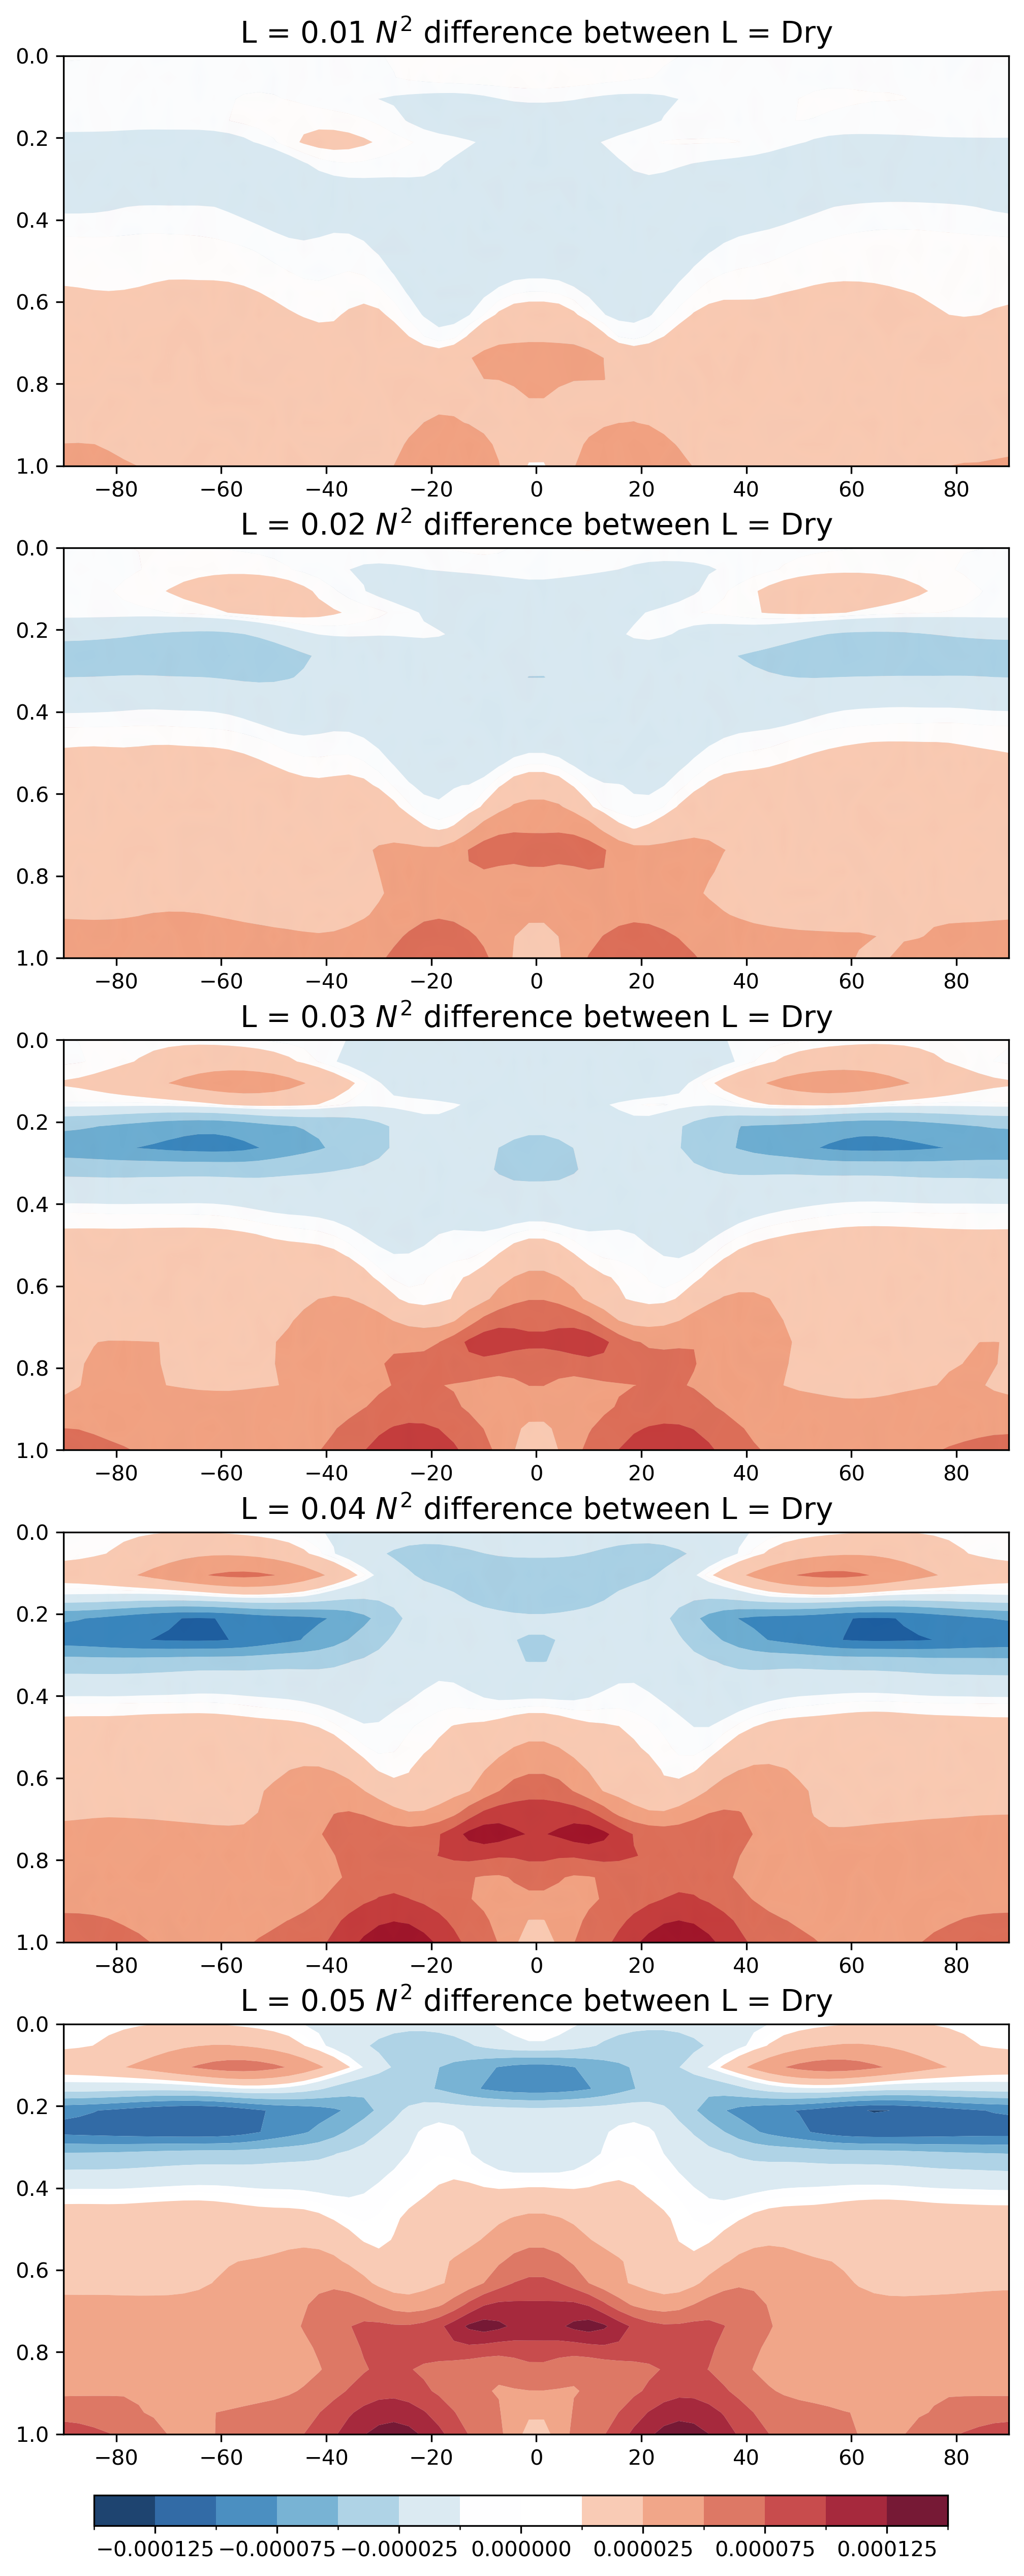

In [150]:
sigma = np.linspace(0,1,20)
y = np.linspace(-90,90,64)
fig, ax = plt.subplots(5, figsize=(8,20), dpi=300.)

# For storing cs to use for colorbar later
cs_for_colorbar = None

for i in range(5):
    N_square_diff = N_square_all[i+1,5000*4:].mean(axis=0) - N_square_all[0,5000*4:].mean(axis=0)
    _, custom_levels_bar2, cs = plot_contourf_near0_fixcolorbar_fig2_3(
        y, sigma, N_square_diff, ax[i], 
        cbar_lim=[-1.5E-4, 1.5E-4],
        my_cmap='RdBu_r'
    )
    ax[i].set_title(f"L = {(i+1)*0.01} $N^2$ difference between L = Dry", fontsize=14)
    cs_for_colorbar = cs  # store the last cs

# Add a horizontal colorbar below the last axis
fig.subplots_adjust(bottom=0.1)  # adjust as needed
cbar_ax = fig.add_axes([0.15, 0.07, 0.7, 0.01])  # [left, bottom, width, height]
fig.colorbar(cs_for_colorbar, cax=cbar_ax, orientation='horizontal')


In [8]:
# Assume u, v, t, p are large NumPy arrays
diagnostics = AtmosphericDiagnostics(u, v, t, p)

# Compute EMF and EHF with Dask
emf, ehf = diagnostics.run_emf_ehf(chunks=(10, 20, 64, 128))

# Assume emf has shape (78000, 20, 64, 128) and is a NumPy array
diagnostics = AtmosphericDiagnostics(u, v, t, p)
d_emf_dy = diagnostics.dEMF_dy(emf, use_dask=True, progress=True)

EMF and EHF progress:
[########################################] | 100% Completed | 103.20 ms
[########################################] | 100% Completed | 204.71 ms
dEMF_dy progress:
[########################################] | 100% Completed | 103.86 ms


(20.0, 0.0)

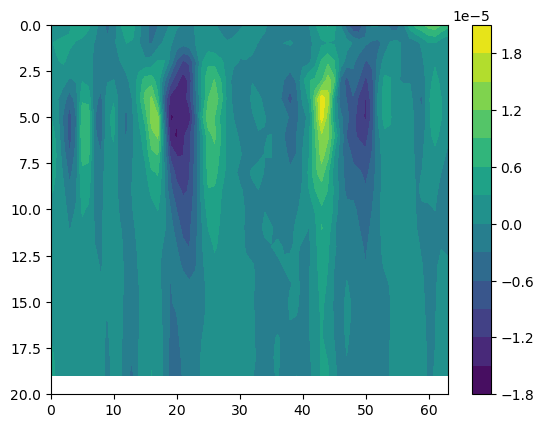

In [9]:
plt.figure()
plt.contourf(d_emf_dy.mean(axis=(0,3)), levels=11)
plt.colorbar()
plt.ylim([20,0])

In [10]:
diagnostics = AtmosphericDiagnostics(u, v, t, p)
theta       = diagnostics.cal_theta(t, p)


In [11]:
theta.shape

(400, 20, 64, 128)

(20.0, 0.0)

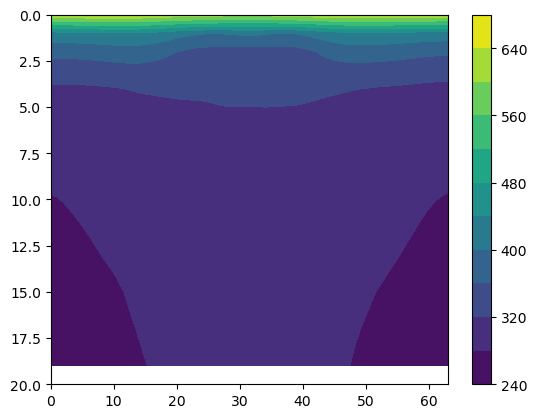

In [12]:
plt.figure()
plt.contourf(theta.mean(axis=(0,-1)), levels=11)
plt.colorbar()
plt.ylim([20,0])

In [13]:
diagnostics = AtmosphericDiagnostics(u, v, t, p)
dtheta, dtheta_correct_neg_val = diagnostics.dtheta(theta)

Computing ∂θ/∂z ...


In [14]:
dtheta_correct_neg_val.shape

(400, 20, 64)

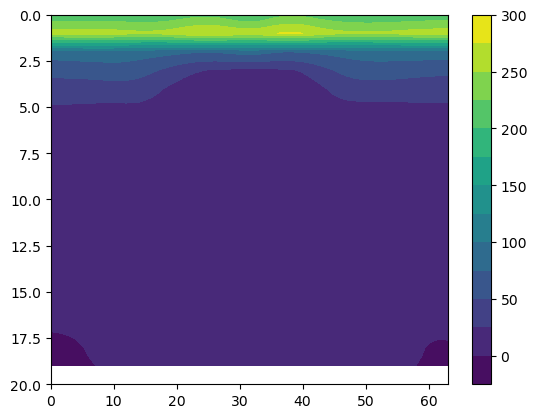

In [15]:
plt.figure()
plt.contourf(dtheta_correct_neg_val.mean(axis=(0)), levels=11)
plt.colorbar()
plt.ylim([20,0])
plt.show()

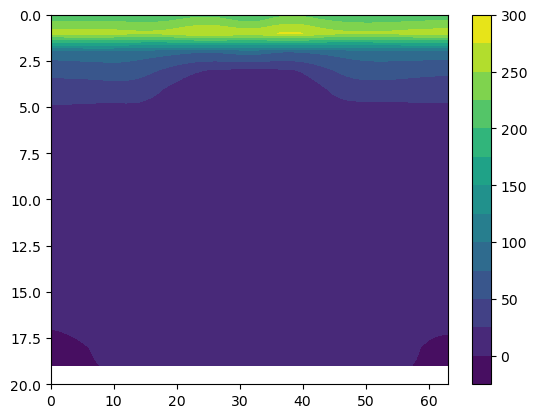

In [16]:
plt.figure()
plt.contourf(dtheta.mean(axis=(0,3)), levels=11)
plt.colorbar()
plt.ylim([20,0])
plt.show()

In [20]:
diagnostics = AtmosphericDiagnostics(u, v, t, p)
dz, dz_correct_neg_val = diagnostics.dtheta(z)

Computing ∂θ/∂z ...


(20.0, 0.0)

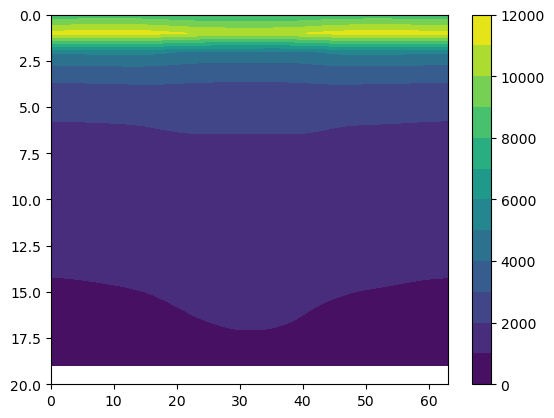

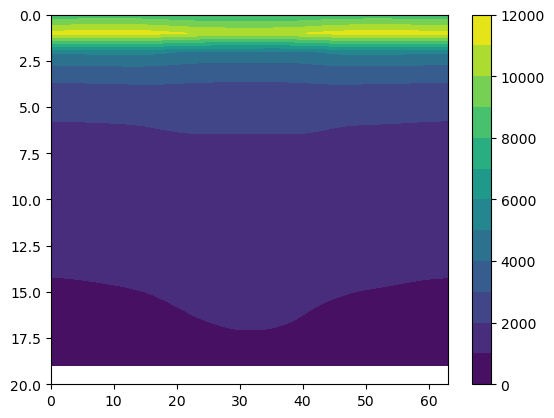

In [24]:
plt.figure()
plt.contourf(dz.mean(axis=(0,3)), levels=11)
plt.colorbar()
plt.ylim([20,0])

plt.figure()
plt.contourf(dz_correct_neg_val.mean(axis=(0)), levels=11)
plt.colorbar()
plt.ylim([20,0])


In [25]:
theta.shape

(400, 20, 64, 128)

In [41]:
theta_zonal_mean = np.mean(theta, axis=-1)
g = 9.81
dthetadz = dtheta_correct_neg_val / dz_correct_neg_val
N_square_test_all = g / theta_zonal_mean * dthetadz


In [42]:
# theta_zonal_mean = np.mean(theta, axis=-1)
# g = 9.81
# dthetadz = np.mean(dtheta/ dz, axis=3) 
# N_square_test_all = g / theta_zonal_mean * dthetadz

(20.0, 0.0)

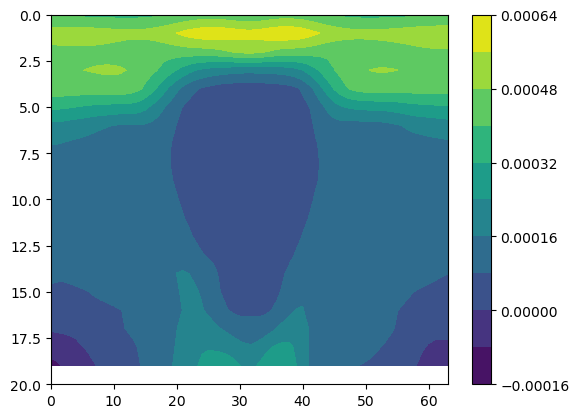

In [43]:
plt.figure()
plt.contourf(N_square_test_all.mean(axis=(0)), levels=11)
plt.colorbar()
plt.ylim([20,0])

In [44]:
# Constant
f0 = 2 * 7.29E-5 * np.sin(np.deg2rad(np.linspace(-90,90,64)))
g  = 9.81

In [52]:
ehf.shape

(400, 20, 64, 128)

In [59]:
# EP flux j and k component
F_j =  emf.mean(axis=(0,3)) # np.mean(EMF, axis=(0,3))
F_k = (f0[np.newaxis, np.newaxis, :] * ehf.mean(axis=3) / N_square_test_all).mean(axis=0)

In [60]:
F_j.shape

(20, 64)

(1.0, 0.0)

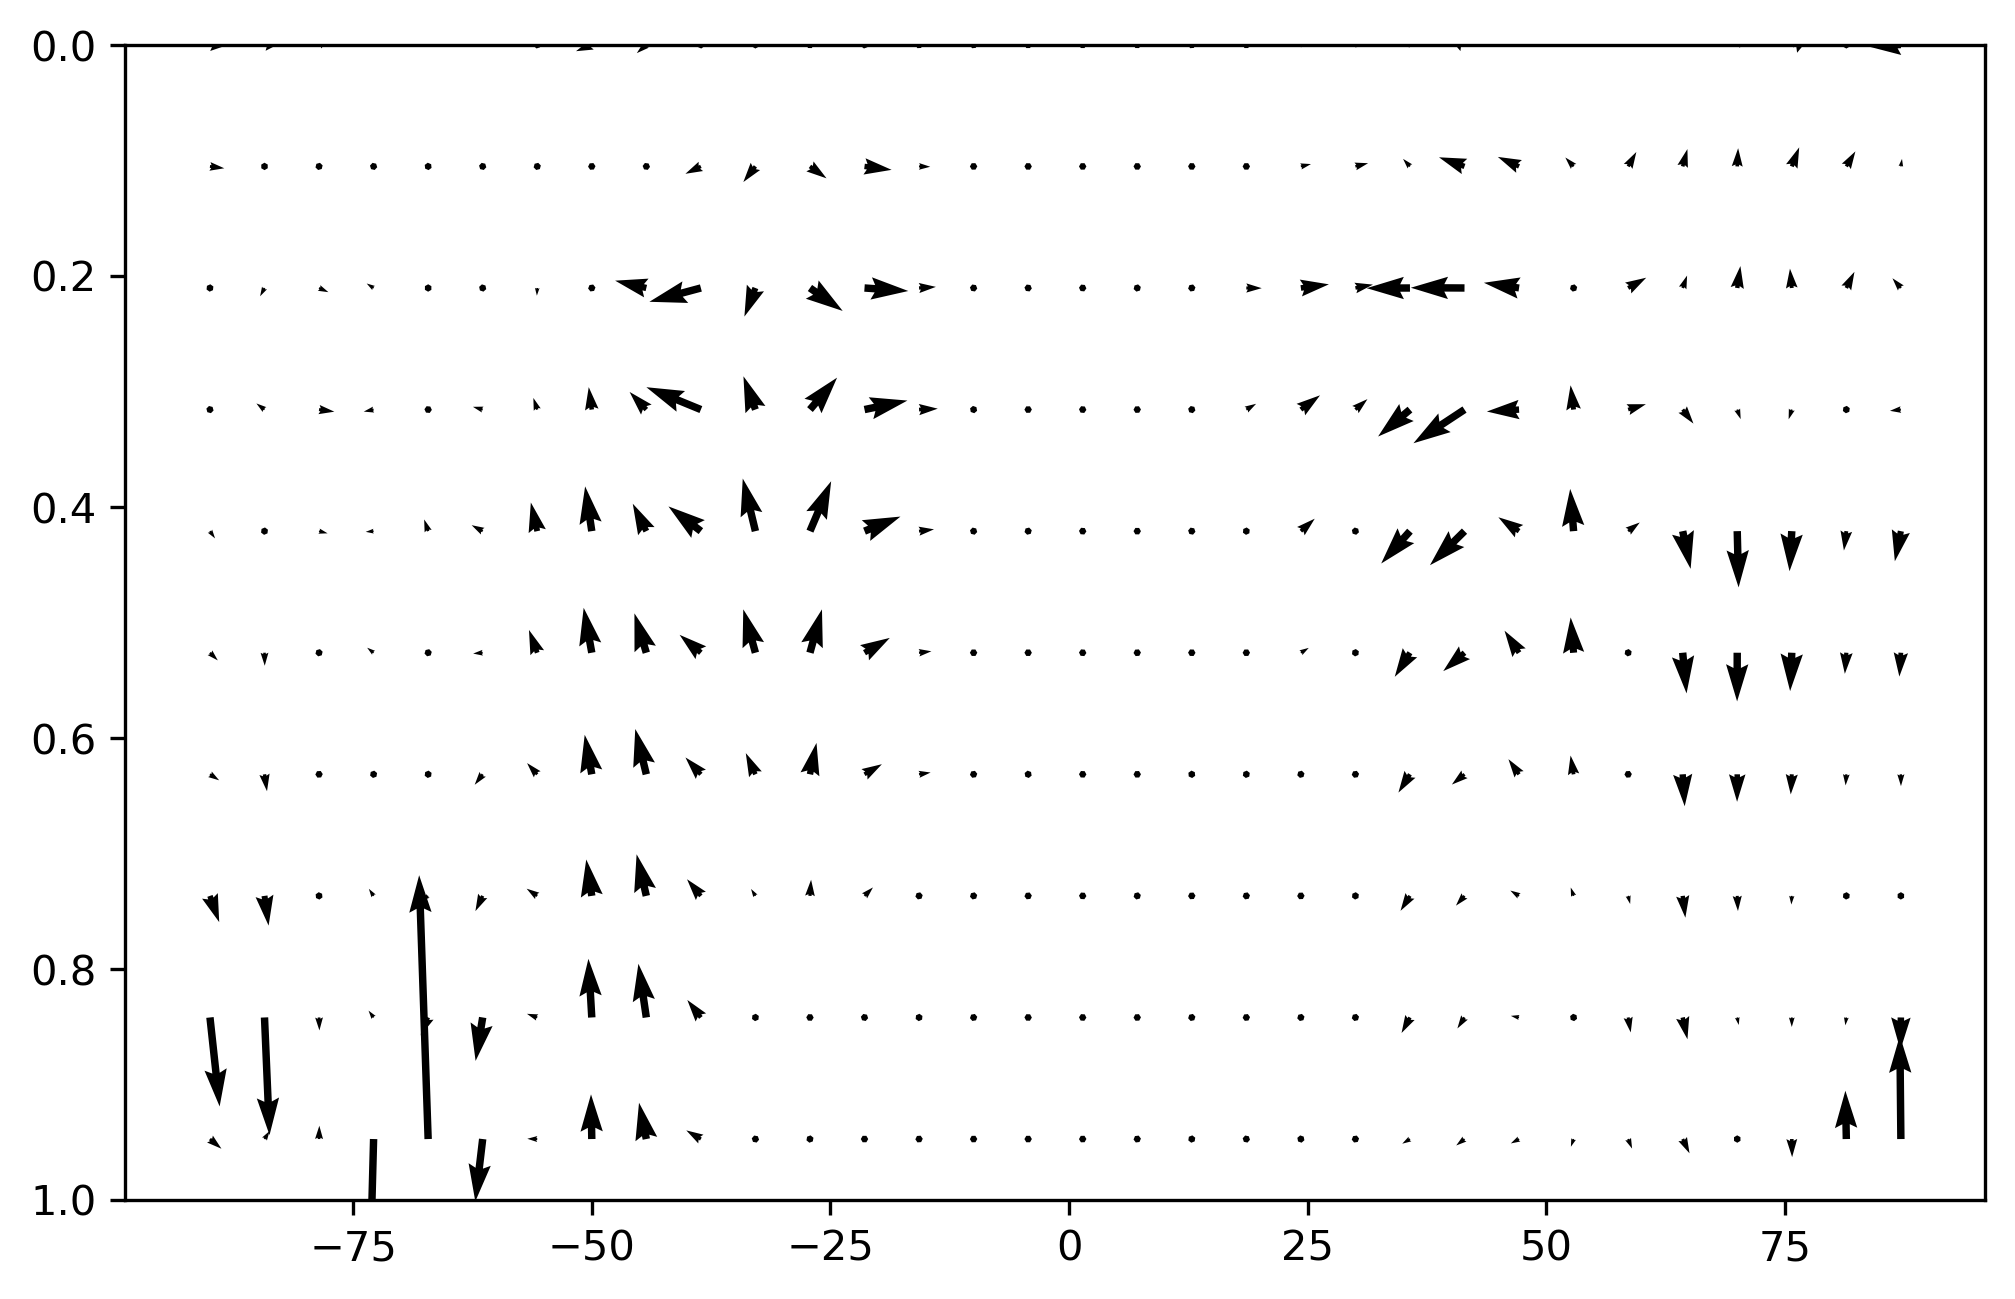

In [61]:
fig, ax = plt.subplots(1, figsize=(8, 5), dpi=300)
y = np.linspace(-90,90,64)
z = np.linspace(0,1,20)
yy, zz = np.meshgrid(y,z)
wind_plt = ax.quiver(yy[::2, ::2], zz[::2, ::2], -F_j[::2, ::2], F_k[::2, ::2],
          color="black", scale_units='xy', angles='xy', width=4e-3, scale=2)
plt.ylim([1,0])